<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 8.9 MB/s eta 0:00:00


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

# **Loading the dataset**

In [ ]:
visa = pd.read_csv("EasyVisa.csv")

In [ ]:
visa.shape

(25480, 12)

# **Overview of the Dataset**

* Strong quality throughout dataset; no duplicates or null values detected.
* The average applicant makes just under $75,000 a year; most applicants hold bachelors or master's degrees.
* Just under 3,000 of the ~ 25,000 applicants require job training.
* 16,000+ applicants are from Asia.
* Over 17,000 applicant records are certified, meaning approved applicants outpace rejected applicats by ~ 2:1 in this dataset.
* Contintent, case status, unit of wage, and full time position all contain heavily skewed values. This will be addressed later on.

In [ ]:
data = visa.copy()
data = data.drop("case_id", axis=1)

In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
data.tail( )

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
round(data.isnull().sum() / data.isnull().count() * 100, 2)


,0
case_id,0.000
continent,0.000
education_of_employee,0.000
has_job_experience,0.000
requires_job_training,0.000
no_of_employees,0.000
yr_of_estab,0.000
region_of_employment,0.000
prevailing_wage,0.000
unit_of_wage,0.000


In [ ]:
data.isna().sum()


,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [ ]:
data.nunique()


,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


In [ ]:
# Making a list of all catrgorical variables
cat_col = [
    "continent",
    "education_of_employee",
    "has_job_experience",
    "requires_job_training",
    "region_of_employment",
    "unit_of_wage",
    "full_time_position",
    "case_status",
]

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 40)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
----------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
----------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
----------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
----------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
----------------------------------------
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64
----------------------------------------
full_time_position
Y    22773
N     2707
Name: count, dtype: int64
--------

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

### What is the core business problem we are solving for?

## Context
* The Office of Foreign Labor (OFLC) is responsible for leading the United States' effort to identify hard-working, talented, and qualified individuals both locally as well as abroad.

* OFLC processes job certification applications for  employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

* In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year.

## Problem Statement
* OFLC teams are required to review every visa application manually, which becomes an increasily tedious task as the number of applicants grow each year.  Without an automated/machine-backed solution, qualified individuals risk their applications being overlooked and more team members will be required to spend time reviewing applications.



### Univariate Analysis
**EDA - Numerical Columns**
* To start Exploratory Data Analysis, I'll create histograms and boxplots for all numerical features.

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

#### Observation on Number of Employees

* This is a heavily right-skewed distribution; most values are very close to 0 while the long tail extends out to 600,000+.

* Majority of companies included are small; likely means very few emplyees and starts or small businesses.

* Mean is pulled far right due to large companies; median will serve as a better representation.

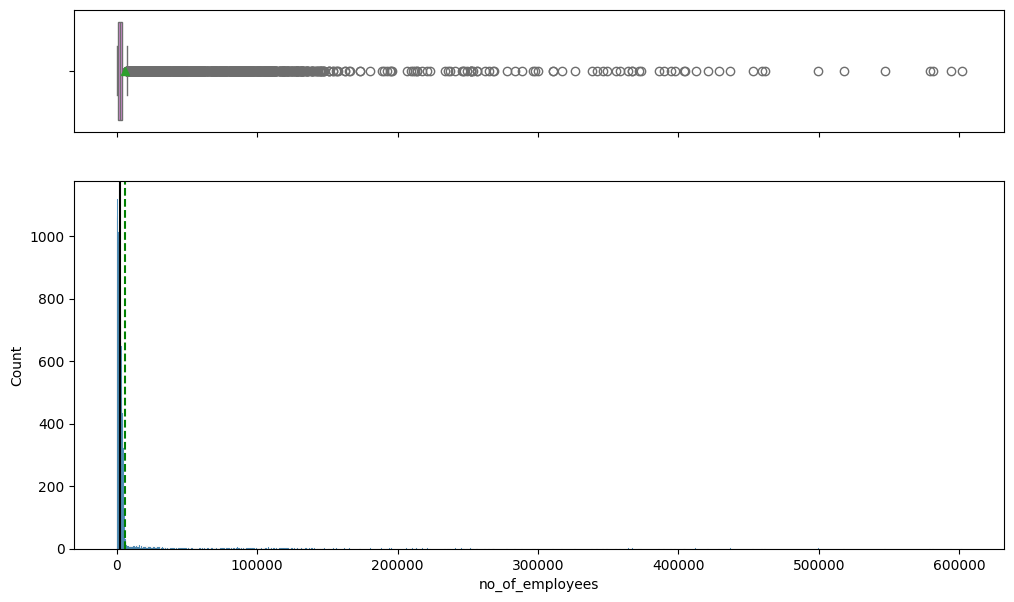

In [ ]:
# Observations on number of employees at each company
histogram_boxplot(data, "no_of_employees")

#### Observation on Years of Establishment
* This is a left-skewed distribution; ~ 75% of companies were established after 1975.

* The boxplot shows that there are outliers on the low end, i.e. companies established before 1940

* We will not treat these outliers as they represent when real companies were established

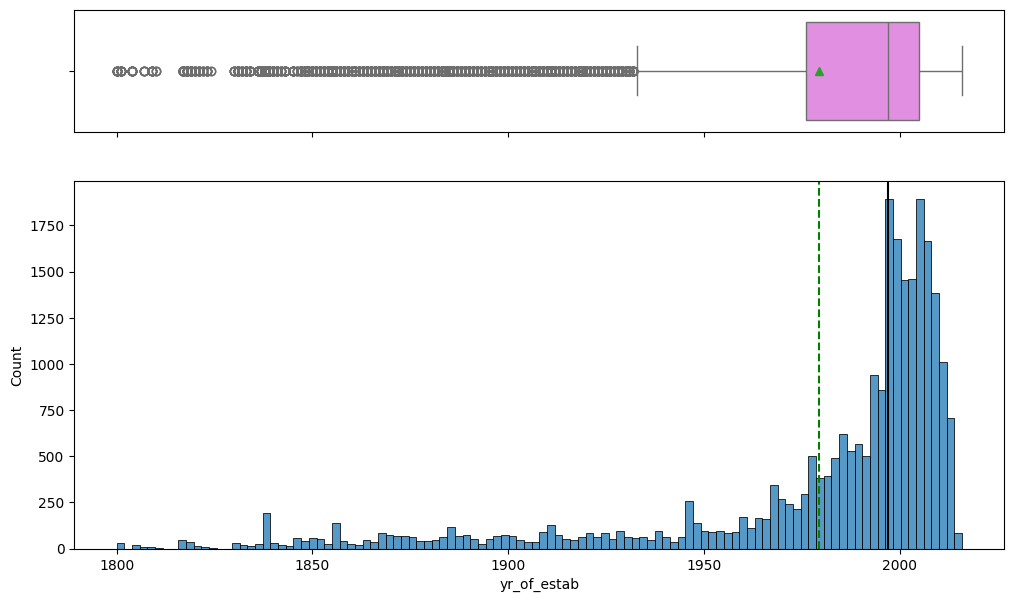

In [ ]:
# Observations on years of establishment for each company
histogram_boxplot(data, "yr_of_estab")

#### Observation on Prevaling wage

* This is a right-skewed distribution; mean and median wages hover around $75,0000.

* The boxplot shows that there are outliers on the high end, possibly due to continent pay discrepancies.

* We will not treat these outliers as they represent real pay differences across different continents.

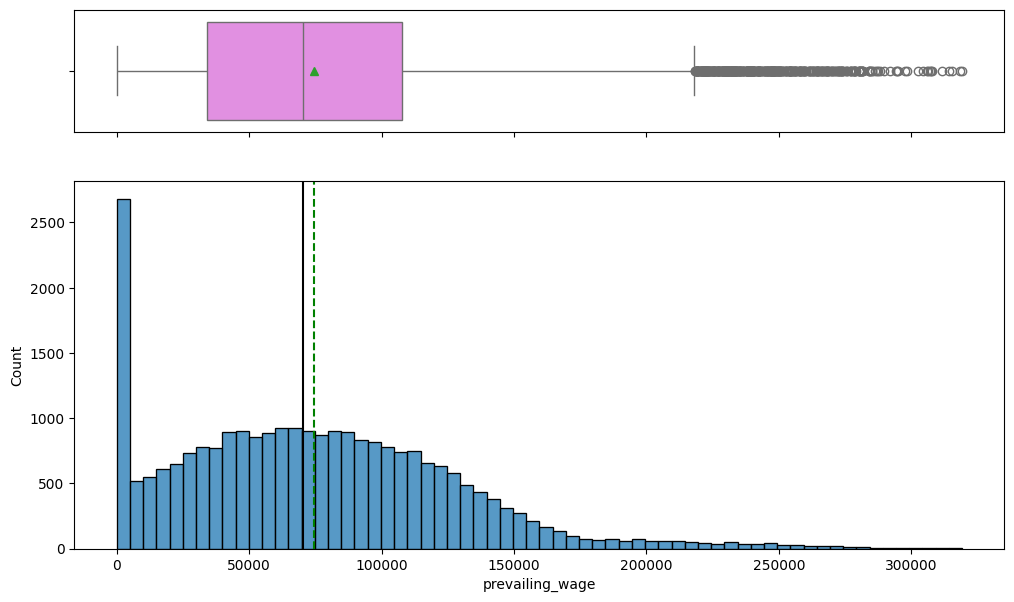

In [ ]:
# Observations on prevailing wage for each applicant
histogram_boxplot(data, "prevailing_wage")

**EDA - Categorical Columns**
* I'll now create bar charts for all categorical features.

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observation on Continent  

* The continent distribution is heavily imbalanced, with Asia holding over 16,000 applications (24,580 in total).

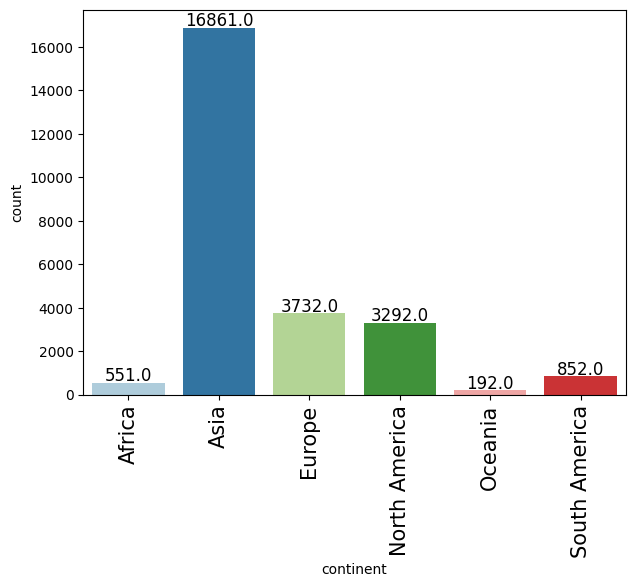

In [ ]:
# observations on continent
labeled_barplot(data, "continent")

#### Observation on Education of Employee

* Applicants with bachelors or masters degree make up nearly 80% of education levels.

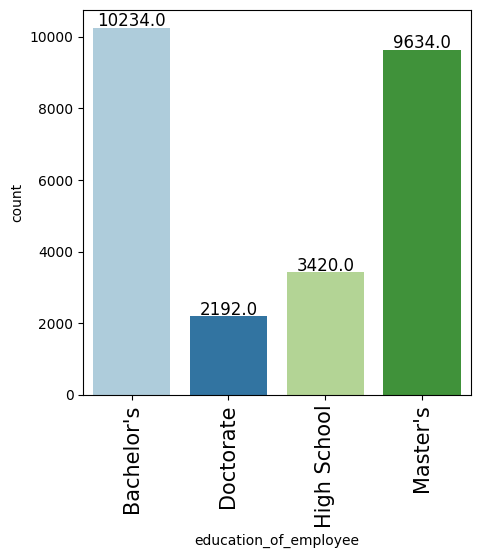

In [ ]:
labeled_barplot(data, "education_of_employee")

#### Observation on Job Experience

* 58% of applicants have previous job experience.

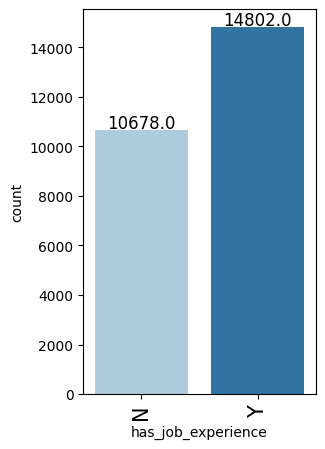

In [ ]:
labeled_barplot(data, "has_job_experience")

#### Observation on Requires Job Training

* Only 12% require job training for visa application; this seems to contradict the above observation, which states 42% of applicants do not have job experience.

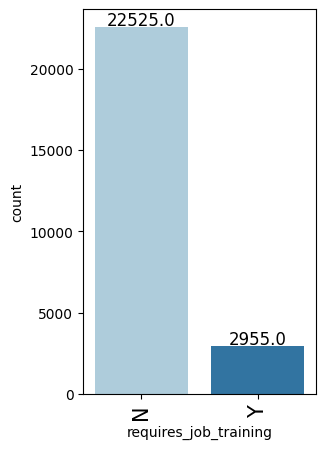

In [ ]:
labeled_barplot(data, "requires_job_training")

#### Observation on Region of Employment

* Nearly 82% of applicants plan to work from the Northeast, South, or West regions of the United States.

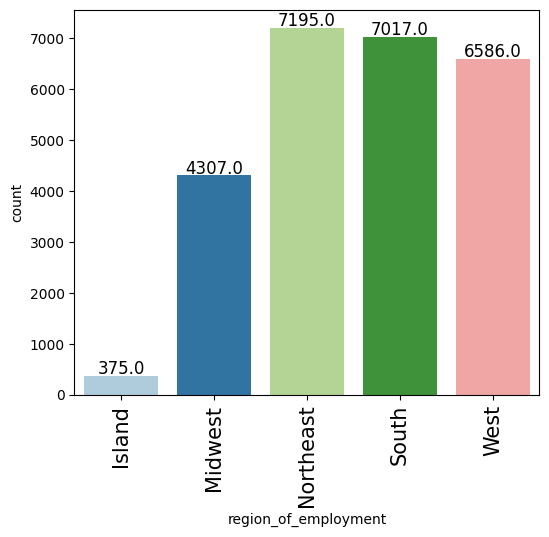

In [ ]:
labeled_barplot(data, "region_of_employment")

#### Observations on Unit of Wage

* 90% of applicants' prevailing wage are expressed in yearly wage.

* 8% of applicants' prevailing wage are expressed in hourly wage.

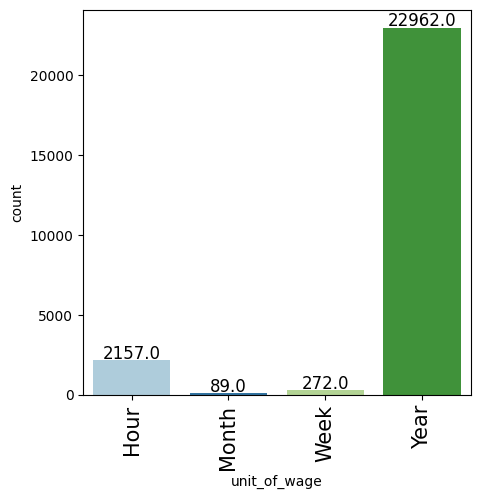

In [ ]:
labeled_barplot(data, "unit_of_wage")

#### Observation on Full Time Position

* 89% of visa applications are related to full time positions.

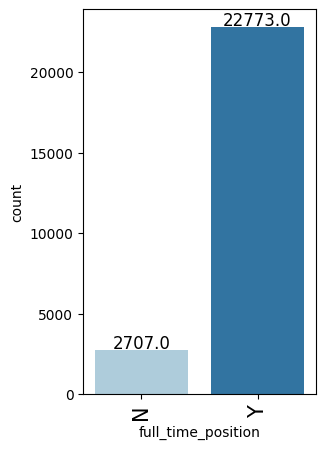

In [ ]:
labeled_barplot(data, "full_time_position")

#### Observation on Case Status

* 67% of applicants from this dataset were ultimately certified, meaning approvals outweigh rejections by nearly 2:1.

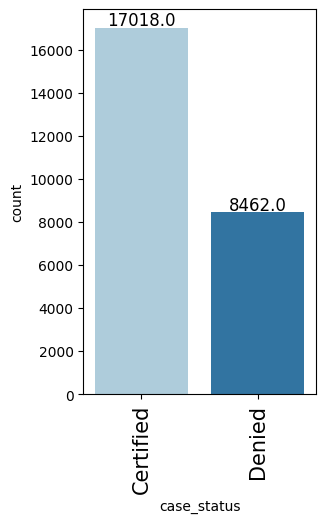

In [ ]:
labeled_barplot(data, "case_status")

### Bivariate Analysis

Bivariate analysis explores variable relationships in three parts:


1.   Numerical variables through a heatmap
2.   Categorical variables through a heatmap
3.   Variable relationships with Case Status

**Relationship Across Numerical Variables**

* Number of employees, year company established, and prevailing wage do not show a positive or negative correlation worth exploring further.

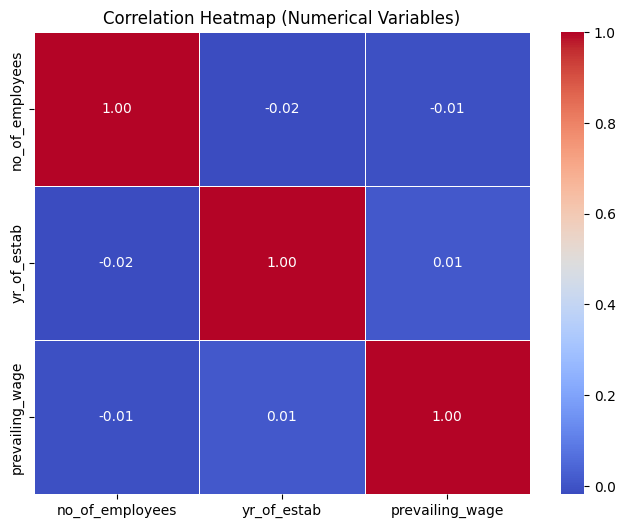

In [ ]:
# Select numerical columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Correlation matrix
corr_matrix = data[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap (Numerical Variables)")
plt.show()

**Relationship Across Categorical Variables**

* The following variables showed a positive correlation to case status:
  * Education of Employee (0.33)
  * Unit of Wage (0.21)
  * Has Job Experience (0.19)


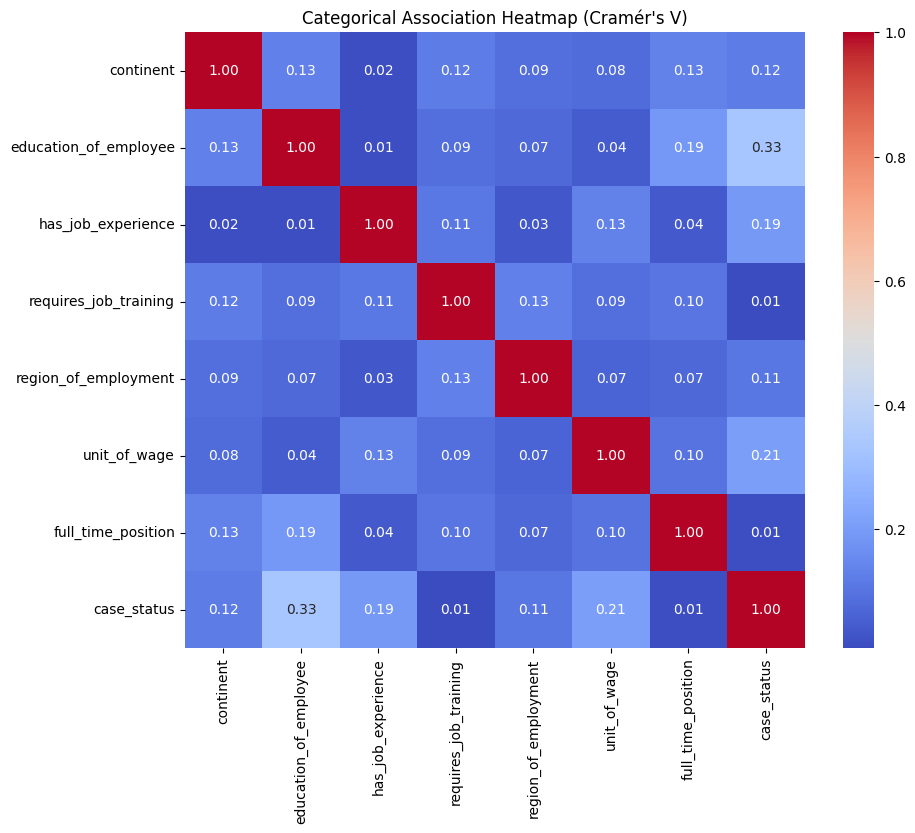

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

# Select categorical columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns

# Create matrix
cramers_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols,
    columns=cat_cols
)

# Fill matrix
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Categorical Association Heatmap (Cramér's V)")
plt.show()

#### Variable Relationships with Case Status

* By education level, employees holding master's degrees are most likely to have their application certified.

* Applicants with previous job experience are more likely to see their visa certified.

* While Asia received the highest number of visa certifications, applicants from Europe were more likely to be certified.

* Applicants not requiring job training are more likely to receive visa certifications.

* Applicants seeking visas in the Midwest region received the highest certification rate.

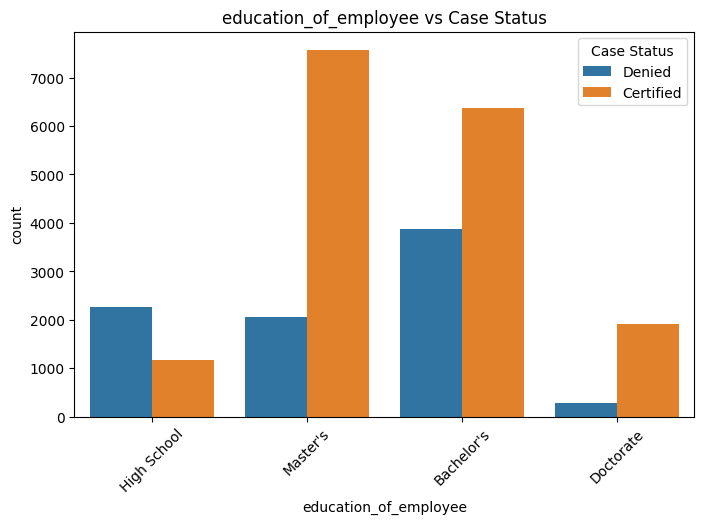

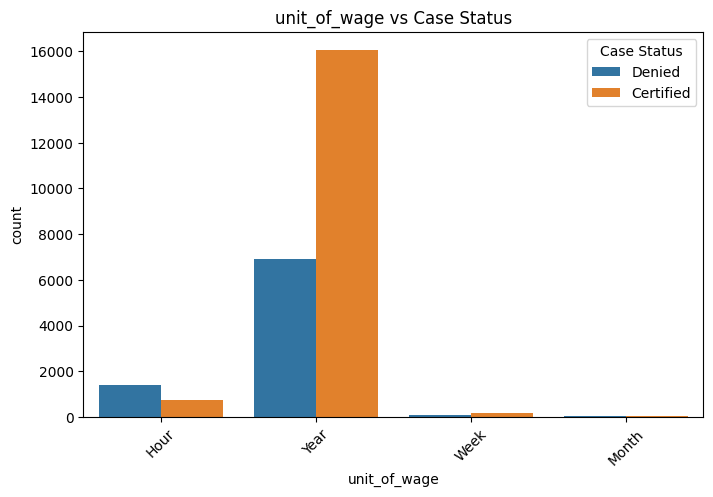

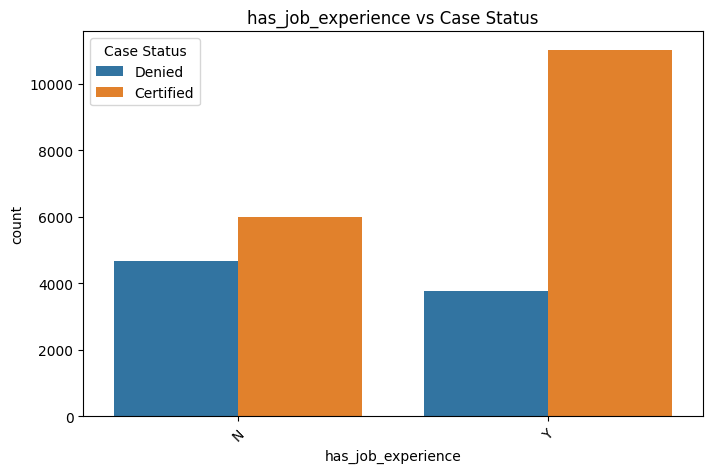

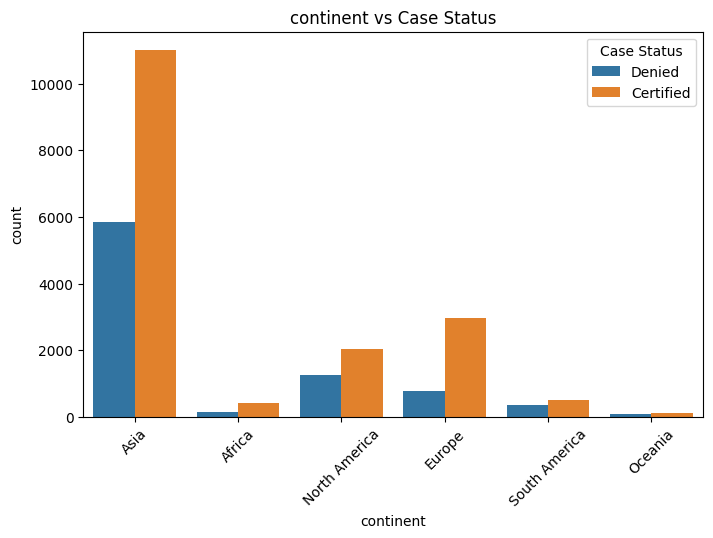

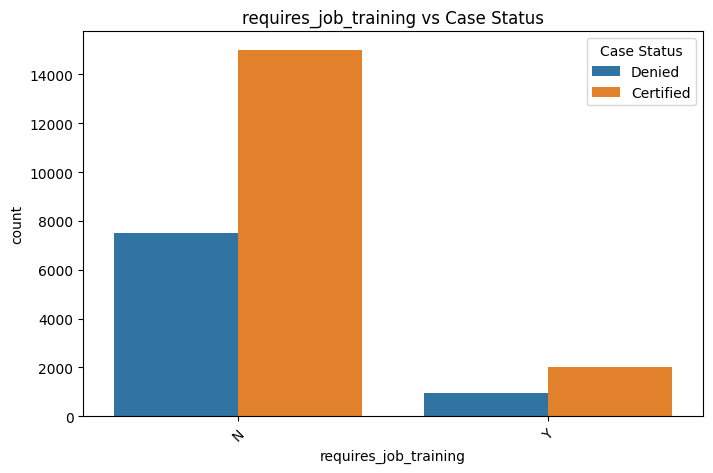

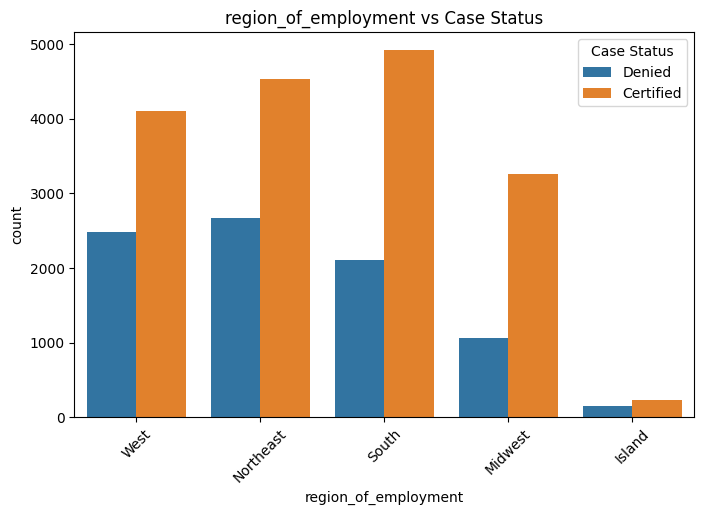

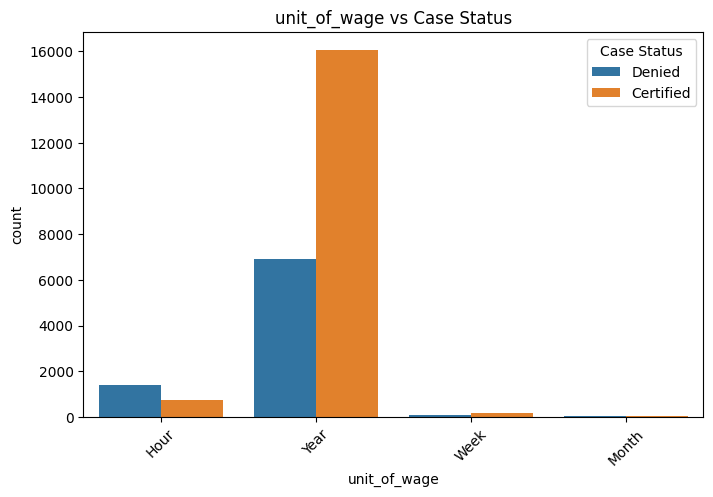

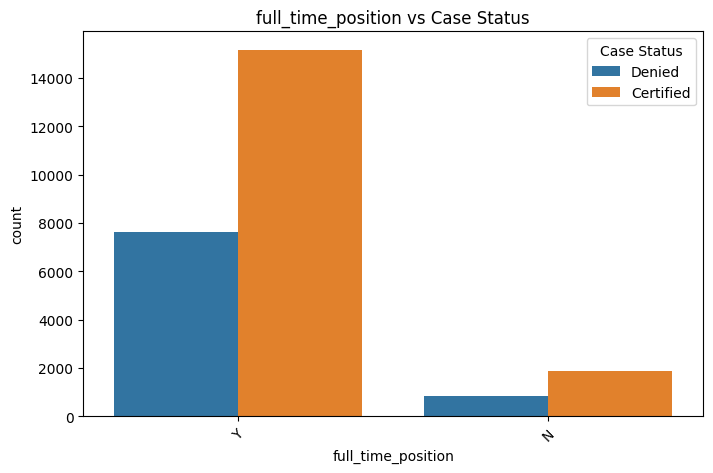

In [ ]:
cat_vars = ["education_of_employee", "unit_of_wage", "has_job_experience", "continent", "requires_job_training", "region_of_employment", "unit_of_wage", "full_time_position"]

for col in cat_vars:
    plt.figure(figsize=(8,5))

    sns.countplot(
        data,
        x=col,
        hue="case_status"
    )

    plt.title(f"{col} vs Case Status")
    plt.xticks(rotation=45)
    plt.legend(title="Case Status")
    plt.show()

# **Data Pre-processing**

### Actions Taken

* During Exploratory Data Analysis, I confirmed no duplicates or null values exist in the dataset.

* While outliers were identified across several variables, I chose to not treat any of the values as the data reflected accurately.

* The case status feature will be seaprated from the remaining data, as case status (certified or denied) will be the predicted value from the model.

* Dataset will be split into train, validation, and test sets.

* To prepare for model building, all categorical variables will be encoded.

In [ ]:
df = data.copy()

df["case_status"] = df["case_status"].map({
    "Certified": 1,
    "Denied": 0
})

X = df.drop("case_status", axis=1)
y = df["case_status"]

In [ ]:
# Splitting data into training, validation and test sets:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 10) (5096, 10) (5096, 10)


In [ ]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_val = pd.get_dummies(data=X_val, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)

# **Model Building**

### When predicting case status, what model evaluation metric should be used?

*Options:* Accuracy, Precision, Recall, F1 Score

* Accuracy → overall correctness (can mislead)
* Precision → quality of positive predictions
* Recall → coverage of actual positives
* F1 Score → balance of precision and recall

### Metric Chosen & Rationale

* In this scenario, the Office of Foreign Labor Certification (OFLC) faces two types of losses:
  * Approving an undeserving applicant - loss of applicant quality
  * Rejecting a deserving applicant - loss of applicant opportunity

Given the features included in this dataset, both scenarios are equal negatives for the OFLC. Additionally, certified applicants appear more frequently than denied applicants in this dataset by a ~ 2:1 ratio.


To balance these nuances, F1 Score will be used as the primary evaluation metric. Precision and Recall will be monitored as secondary metrics.




### Model Building - Original Data

Helper Functions

In [ ]:
def evaluate_on_validation(model, X_train, X_val, y_train, y_val, model_name):
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1 Score": f1_score(y_val, y_val_pred)
    }
    return model, metrics

In [ ]:
def evaluate_on_test(model, X_test, y_test, model_name):
    y_test_pred = model.predict(X_test)

    print(f"\n{'='*60}")
    print(f"Final Test Results: {model_name}")
    print(f"{'='*60}")
    print("Accuracy :", round(accuracy_score(y_test, y_test_pred), 4))
    print("Precision:", round(precision_score(y_test, y_test_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_test_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_test_pred), 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

Define Models

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}

### Evaluating Model Performance on Validation Set (Original Data)

* Four models posted F1 Scores around 82% - Gradient Boosting, Bagging, XGBoost, and AdaBoost.

* These four models posted strong recall scores, meaning they are catching most of the actual certified cases. However, lower precision scores suggest ~ 25% of ceritified predictions are incorrect.

* The other two models with lower F1 Scores between 76% and 79% (Decision Tree and Random Forsest) have the opposite problem. These models predict incorrect certified applicants at a lower rate (higher precision scores) BUT miss more real certified cases (lower recall scores).

In [ ]:
validation_results = []
trained_models = {}

for model_name, model in models.items():
    trained_model, metrics = evaluate_on_validation(
        model, X_train, X_val, y_train, y_val, model_name
    )
    trained_models[model_name] = trained_model
    validation_results.append(metrics)

validation_results_df = pd.DataFrame(validation_results)
validation_results_df = validation_results_df.sort_values(by="F1 Score", ascending=False)

print("\nValidation Results:")
print(validation_results_df)


Validation Results:
               Model  Accuracy  Precision  Recall  F1 Score
4  Gradient Boosting     0.755      0.783   0.874     0.826
2            Bagging     0.739      0.751   0.911     0.823
5            XGBoost     0.751      0.783   0.868     0.823
3           AdaBoost     0.719      0.725   0.933     0.816
1      Random Forest     0.729      0.819   0.764     0.790
0      Decision Tree     0.708      0.821   0.719     0.767


### Model Building - Oversampled Data

Creating oversampled training data - using SMOTE technique

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply only to training data
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print("Original training distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_over).value_counts())

Original training distribution:
case_status
1    10210
0     5078
Name: count, dtype: int64

After SMOTE:
case_status
0    10210
1    10210
Name: count, dtype: int64


### Evaluating Model Performance on Validation Set (Oversampled Data)

* All six models posted similar F1 scores, ranging from 81.3% to 82.1%.

* Two models (Bagging and AdaBoost) posted Recall scores above 90%. However, these two models posted the lowest Precision scores, showing an aggressive model that approves a slightly higher number of undeserving applicants.

* Conversely, the two models with the highest Precision scores (XGBoost, Random Forest) posted the lowest Recall scores. These results show a more conservative model that rejects a slightly higher number of deserving applicants.

In [ ]:
oversampled_results = []
trained_models_over = {}

for model_name, model in models_under.items():  # reuse same models dict
    trained_model, metrics = evaluate_on_validation(
        model,
        X_train_over,
        X_val,            # original validation set
        y_train_over,
        y_val,
        model_name
    )
    trained_models_over[model_name] = trained_model
    oversampled_results.append(metrics)

oversampled_results_df = pd.DataFrame(oversampled_results)
oversampled_results_df = oversampled_results_df.sort_values(by="F1 Score", ascending=False)

print("\nValidation Results on Oversampled Training Data:")
print(oversampled_results_df)


Validation Results on Oversampled Training Data:
               Model  Accuracy  Precision  Recall  F1 Score
2            Bagging     0.737      0.754   0.902     0.821
5            XGBoost     0.750      0.787   0.858     0.821
1      Random Forest     0.746      0.782   0.859     0.819
0      Decision Tree     0.734      0.754   0.895     0.818
3           AdaBoost     0.728      0.742   0.910     0.817
4  Gradient Boosting     0.743      0.791   0.835     0.813


### Model Building - Undersampled Data

Creating undersampled training data

In [ ]:
from sklearn.utils import resample
train_df = X_train.copy()
train_df["case_status"] = y_train.values

# Split majority and minority classes
majority_class = train_df[train_df["case_status"] == 1]   # Certified
minority_class = train_df[train_df["case_status"] == 0]   # Denied

print("Original training class counts:")
print(train_df["case_status"].value_counts())

# Undersample majority class to match minority class
majority_downsampled = resample(
    majority_class,
    replace=False,                     # no duplication
    n_samples=len(minority_class),     # match minority count
    random_state=42
)

# Combine minority class with downsampled majority class
train_df_under = pd.concat([majority_downsampled, minority_class])

# Shuffle rows
train_df_under = train_df_under.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nUndersampled training class counts:")
print(train_df_under["case_status"].value_counts())

# Separate back into X/y
X_train_under = train_df_under.drop("case_status", axis=1)
y_train_under = train_df_under["case_status"]

Original training class counts:
case_status
1    10210
0     5078
Name: count, dtype: int64

Undersampled training class counts:
case_status
0    5078
1    5078
Name: count, dtype: int64


In [ ]:
def evaluate_on_validation(model, X_train, X_val, y_train, y_val, model_name):
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1 Score": f1_score(y_val, y_val_pred)
    }
    return model, metrics

In [ ]:
models_under = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),

    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}

### Evaluating Model Performance on Validation Set (Undersampled Data)

* All six models posted F1 Scores between 76.4% and 78.6%.

* These models are the most conservative so far, as none of the six trained models posted Recall scores above 80%.

* As a result of the lower Recall scores, however, all six models posted strong Precision scores at nearly 80% or above.

In [ ]:
undersampled_results = []
trained_models_under = {}

for model_name, model in models_under.items():
    trained_model, metrics = evaluate_on_validation(
        model,
        X_train_under,
        X_val,              # original validation set
        y_train_under,
        y_val,              # original validation labels
        model_name
    )
    trained_models_under[model_name] = trained_model
    undersampled_results.append(metrics)

undersampled_results_df = pd.DataFrame(undersampled_results)
undersampled_results_df = undersampled_results_df.sort_values(by="F1 Score", ascending=False)

print("\nValidation Results on Undersampled Training Data:")
print(undersampled_results_df)


Validation Results on Undersampled Training Data:
               Model  Accuracy  Precision  Recall  F1 Score
3           AdaBoost     0.718      0.796   0.778     0.787
1      Random Forest     0.725      0.820   0.754     0.785
4  Gradient Boosting     0.718      0.831   0.726     0.775
5            XGBoost     0.712      0.835   0.709     0.767
0      Decision Tree     0.707      0.825   0.712     0.765
2            Bagging     0.707      0.828   0.709     0.764


In [ ]:
original_results = validation_results_df.copy()
original_results["Dataset"] = "Original"

undersampled_results_df["Dataset"] = "Undersampled"
oversampled_results_df["Dataset"] = "Oversampled"

comparison_df = pd.concat([
    original_results,
    undersampled_results_df,
    oversampled_results_df
], ignore_index=True)

comparison_df = comparison_df.sort_values(by=["F1 Score", "Dataset"])

print(comparison_df)

                Model  Accuracy  Precision  Recall  F1 Score       Dataset
11            Bagging     0.707      0.828   0.709     0.764  Undersampled
10      Decision Tree     0.707      0.825   0.712     0.765  Undersampled
5       Decision Tree     0.708      0.821   0.719     0.767      Original
9             XGBoost     0.712      0.835   0.709     0.767  Undersampled
8   Gradient Boosting     0.718      0.831   0.726     0.775  Undersampled
7       Random Forest     0.725      0.820   0.754     0.785  Undersampled
6            AdaBoost     0.718      0.796   0.778     0.787  Undersampled
4       Random Forest     0.729      0.819   0.764     0.790      Original
17  Gradient Boosting     0.743      0.791   0.835     0.813   Oversampled
3            AdaBoost     0.719      0.725   0.933     0.816      Original
16           AdaBoost     0.728      0.742   0.910     0.817   Oversampled
15      Decision Tree     0.734      0.754   0.895     0.818   Oversampled
14      Random Forest    

### Comparing Models and Selecting the Best Performing Models

* Of the 18 models trained, the top 11 models were all based on the original or oversampled dataset. Undersampled models consistently performed worse in comparison, though the difference in F1 Scores is fairly small.

* Bagging and XGBoost Models performed well across the oversampled and original datasets, posting 4 of the 5 highest F1 scores.

* Given our imperative to focus on F1 score, I'll begin hyperparameter tuning with the Gradient Boosting, XGBoost, and Bagging models from the original dataset.

# **Model Performance Improvement**

* I will tune Gradient Boosting, XGBoost, and Bagging models from the original dataset using GridSearchCV and RandomizedSearchCV. I will also compare the performance and time taken by these two methods - grid search and randomized search.



In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Gradient Boosting

Gradient Boosting Model Results - Before Hyperparameter Tuning:
* Accuracy: 0.755
* Precision: 0.783
* Recall: 0.874
* F1 Score: 0.826

GridSearchCV - Validation performance:
* Accuracy: 0.748
* Precision: 0.767
* Recall: 0.894
* F1 Score: 0.826

RandomizedSearchCV - Validation performance:
* Accuracy: 0.750
* Precision: 0.767
* Recall: 0.899
* F1 Score: 0.828

In summary, hyperparameter tuning the Gradient Boosting model very slightly increased F1 Score by improving recall at the cost of precision (model becomes slightly more aggressive).


#### GridSearchCV

In [ ]:
# Creating pipeline
from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer
model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in GridSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(f1_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(
    "Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_)
)

Best Parameters:{'init': AdaBoostClassifier(random_state=1), 'learning_rate': 0.05, 'max_features': 0.7, 'n_estimators': np.int64(50), 'subsample': 0.7} 
Score: 0.8254925690476862


In [ ]:
# Creating new pipeline with best parameters
GB_tuned1 = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), learning_rate=0.05, max_features=0.7, n_estimators=np.int64(50), subsample=0.7
)

# Fit the model on training data
GB_tuned1.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.7,
                           n_estimators=np.int64(50), subsample=0.7)

In [ ]:
# Calculating different metrics on train set
GB_grid_train = model_performance_classification_sklearn(
    GB_tuned1, X_train, y_train
)
print("Training performance:")
GB_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.749,0.898,0.766,0.827


In [ ]:
# Calculating different metrics on validation set
GB_grid_val = model_performance_classification_sklearn(GB_tuned1, X_val, y_val)
print("Validation performance:")
GB_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.748,0.894,0.767,0.826


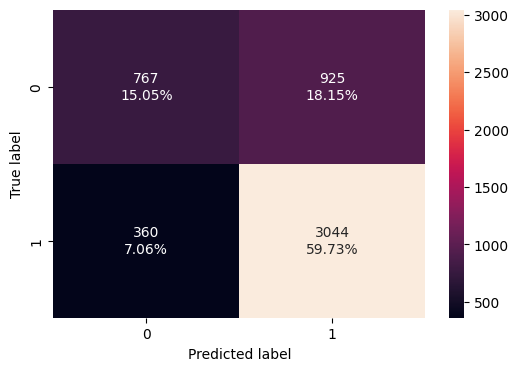

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(GB_tuned1, X_val, y_val)

#### RandomizedSearchCV

In [ ]:
# Creating pipeline
model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
# Type of scoring used to compare parameter combinations
scorer = make_scorer(f1_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv.best_params_, randomized_cv.best_score_
    )
)

Best parameters are {'subsample': 0.7, 'n_estimators': np.int64(50), 'max_features': 0.7, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8254925690476862:


In [ ]:
# Creating new pipeline with best parameters
GB_tuned2 = GradientBoostingClassifier(
subsample=0.7, n_estimators=np.int64(50), max_features=0.7, learning_rate=0.05, init=AdaBoostClassifier(random_state=1)
)

# Fit the model on training data
GB_tuned2.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.7,
                           n_estimators=np.int64(50), subsample=0.7)

In [ ]:
# Calculating different metrics on train set
GB_random_train = model_performance_classification_sklearn(
    GB_tuned2, X_train, y_train
)
print("Training performance:")
GB_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.750,0.901,0.766,0.828


In [ ]:
# Calculating different metrics on validation set
GB_random_val = model_performance_classification_sklearn(GB_tuned2, X_val, y_val)
print("Validation performance:")
GB_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.750,0.899,0.767,0.828


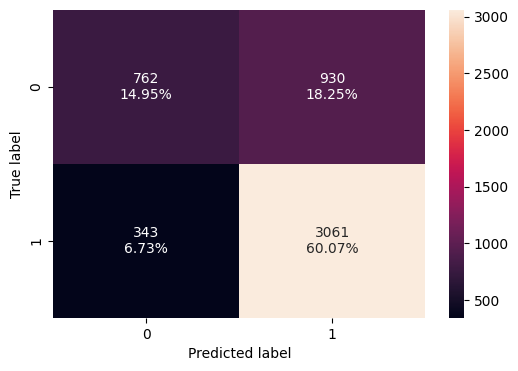

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(GB_tuned2, X_val, y_val)

### Bagging

Bagging Model Results - Before Hyperparameter Tuning:

* Accuracy: 0.739
* Precision: 0.751
* Recall: 0.911
* F1 Score: 0.823

GridSearchCV - Validation performance:

* Accuracy: 0.730
* Precision: 0.758
* Recall: 0.874
* F1 Score: 0.812

RandomizedSearchCV - Validation performance:

* Accuracy: 0.727
* Precision: 0.757
* Recall: 0.871
* F1 Score: 0.810

Tuning the Bagging Model resulted in worse performance across F1 score, recall, and precision metrics.

#### GridSearchCV

In [ ]:
model = BaggingClassifier(random_state=1)

# Parameter grid to pass in GridSearchCV
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(f1_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(
    "Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_)
)

Best Parameters:{'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 70} 
Score: 0.8142527052862615


In [ ]:
# Creating new pipeline with best parameters
bag_tuned1 = BaggingClassifier(
    max_features=0.8, max_samples=0.8, n_estimators=70
)

# Fit the model on training data
bag_tuned1.fit(X_train, y_train)

BaggingClassifier(max_features=0.8, max_samples=0.8, n_estimators=70)

In [ ]:
# Calculating different metrics on train set
bag_grid_train = model_performance_classification_sklearn(
    bag_tuned1, X_train, y_train
)
print("Training performance:")
bag_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.998,1.000,0.997,0.999


In [ ]:
# Calculating different metrics on validation set
bag_grid_val = model_performance_classification_sklearn(bag_tuned1, X_val, y_val)
print("Validation performance:")
bag_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.730,0.874,0.758,0.812


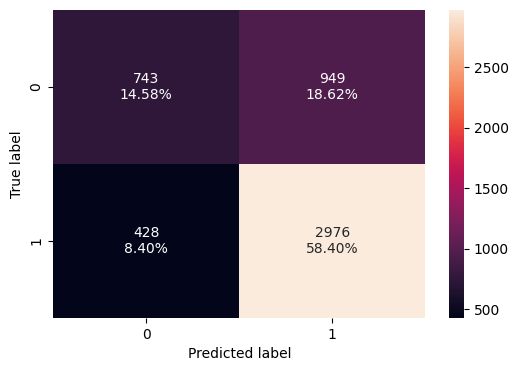

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(bag_tuned1, X_val, y_val)

#### RandomizedSearchCV

In [ ]:
# Creating pipeline
model = BaggingClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
# Type of scoring used to compare parameter combinations
scorer = make_scorer(f1_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv.best_params_, randomized_cv.best_score_
    )
)

Best parameters are {'n_estimators': 70, 'max_samples': 0.9, 'max_features': 0.8} with CV score=0.8131535011235271:


In [ ]:
# Creating new pipeline with best parameters
bag_tuned2 = BaggingClassifier(
n_estimators=70, max_samples=0.9, max_features=0.8
)

# Fit the model on training data
bag_tuned2.fit(X_train, y_train)

BaggingClassifier(max_features=0.8, max_samples=0.9, n_estimators=70)

In [ ]:
# Calculating different metrics on train set
bag_random_train = model_performance_classification_sklearn(
    bag_tuned2, X_train, y_train
)
print("Training performance:")
bag_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


In [ ]:
# Calculating different metrics on validation set
bag_random_val = model_performance_classification_sklearn(bag_tuned2, X_val, y_val)
print("Validation performance:")
bag_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.727,0.871,0.757,0.810


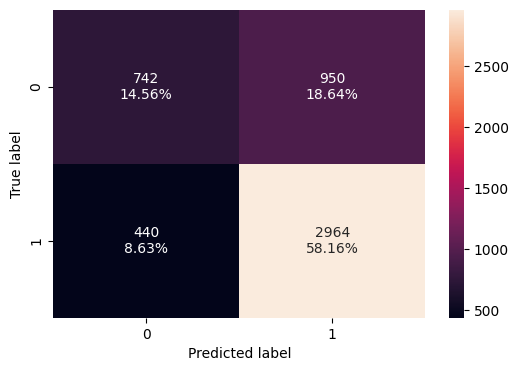

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(bag_tuned2, X_val, y_val)

### XGBoost

XGBoost Model Results - Before Hyperparameter Tuning:

* Accuracy: 0.751
* Precision: 0.783
* Recall: 0.868
* F1 Score: 0.823

GridSearchCV - Validation performance:

* Accuracy: 0.751
* Precision: 0.777
* Recall: 0.880
* F1 Score: 0.825

RandomizedSearchCV - Validation performance:

* Accuracy: 0.751
* Precision: 0.777
* Recall: 0.880
* F1 Score: 0.825

Tuning XGBoost model resulted in slighlt F1 Score improvements using both GridSearchCV and RandomizedSearchCV when compared to the original model.

#### GridSearchCV

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(random_state=1)

# Parameter grid to pass in GridSearchCV
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}

# Type of scoring used to compare parameter combinations
scorer = make_scorer(f1_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(
    "Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_)
)

Best Parameters:{'gamma': 3, 'learning_rate': 0.05, 'n_estimators': np.int64(50), 'scale_pos_weight': 1, 'subsample': 0.7} 
Score: 0.8248550101639676


In [ ]:
# Creating new pipeline with best parameters
xgb_tuned1 = XGBClassifier(
    gamma=3, learning_rate=0.05, n_estimators=np.int64(50), scale_pos_weight=1, subsample=0.7
)

# Fit the model on training data
xgb_tuned1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None,
              n_estimators=np.int64(50), n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Calculating different metrics on train set
xgb_grid_train = model_performance_classification_sklearn(
    xgb_tuned1, X_train, y_train
)
print("Training performance:")
xgb_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.761,0.889,0.782,0.832


In [ ]:
# Calculating different metrics on validation set
xgb_grid_val = model_performance_classification_sklearn(xgb_tuned1, X_val, y_val)
print("Validation performance:")
xgb_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.751,0.880,0.777,0.825


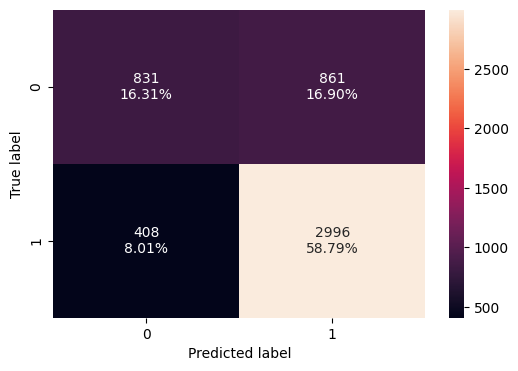

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(xgb_tuned1, X_val, y_val)

#### RandomizedSearchCV

In [ ]:
# Creating pipeline
model = XGBClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
# Type of scoring used to compare parameter combinations
scorer = make_scorer(f1_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print(
    "Best parameters are {} with CV score={}:".format(
        randomized_cv.best_params_, randomized_cv.best_score_
    )
)

Best parameters are {'subsample': 0.7, 'scale_pos_weight': 1, 'n_estimators': np.int64(50), 'learning_rate': 0.05, 'gamma': 3} with CV score=0.8248550101639676:


In [ ]:
# Creating new pipeline with best parameters
xgb_tuned2 = XGBClassifier(
subsample=0.7, scale_pos_weight=1, n_estimators=np.int64(50), learning_rate=0.05, gamma=3
)

# Fit the model on training data
xgb_tuned2.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None,
              n_estimators=np.int64(50), n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Calculating different metrics on train set
xgb_random_train = model_performance_classification_sklearn(
    xgb_tuned2, X_train, y_train
)
print("Training performance:")
xgb_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.761,0.889,0.782,0.832


In [ ]:
# Calculating different metrics on validation set
xgb_random_val = model_performance_classification_sklearn(xgb_tuned2, X_val, y_val)
print("Validation performance:")
xgb_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.751,0.880,0.777,0.825


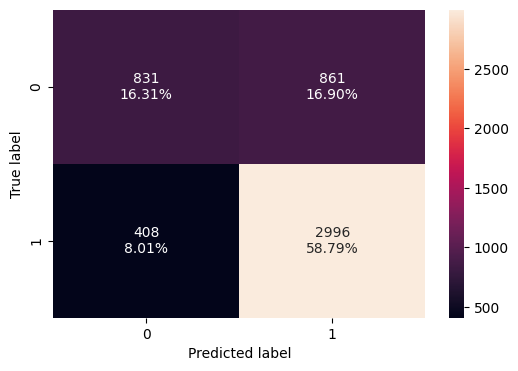

In [ ]:
# creating confusion matrix
confusion_matrix_sklearn(xgb_tuned2, X_val, y_val)

# **Model Comparison and Final Model Selection**

* Using tuners GridSearchCV and RandomizedSearchCV for Gradient Boosting and XGBoosting resulted in strong performance on the validation set.

* Given our interest in balancing certified and rejected applicants, Gradient Boosting Tuned with Random search model ultimately performed best, posting the highest F1 Score and Recall score.

* However, when the Gradient Boosting Tuned with Random search model was used on the previously unseen test set, performance degregaded. The tuned model exhibited slightly lower performance on the unseen test set compared to the original Gradient Boosting model (before tuning).

* Given the relatively small differences between the original dataset and tuned models, combined with a moderate class imbalance, the original Gradient Boosting model was selected at the final model.

In [ ]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        GB_grid_val.T,
        GB_random_val.T,
        xgb_grid_val.T,
        xgb_random_val.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting Tuned with Grid search",
    "Gradient Boosting Tuned with Random search",
    "Xgboost Tuned with Grid search",
    "Xgboost Tuned with Random Search",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boosting Tuned with Grid search,Gradient Boosting Tuned with Random search,Xgboost Tuned with Grid search,Xgboost Tuned with Random Search
Accuracy,0.748,0.750,0.751,0.751
Recall,0.894,0.899,0.880,0.880
Precision,0.767,0.767,0.777,0.777
F1,0.826,0.828,0.825,0.825


In [ ]:
# Let's check the performance on test set
Model_test = model_performance_classification_sklearn(GB_tuned2, X_test, y_test)
Model_test

,Accuracy,Recall,Precision,F1
0,0.735,0.894,0.754,0.818


#### Measuring Feature Importance using the original Gradient Boosting Model

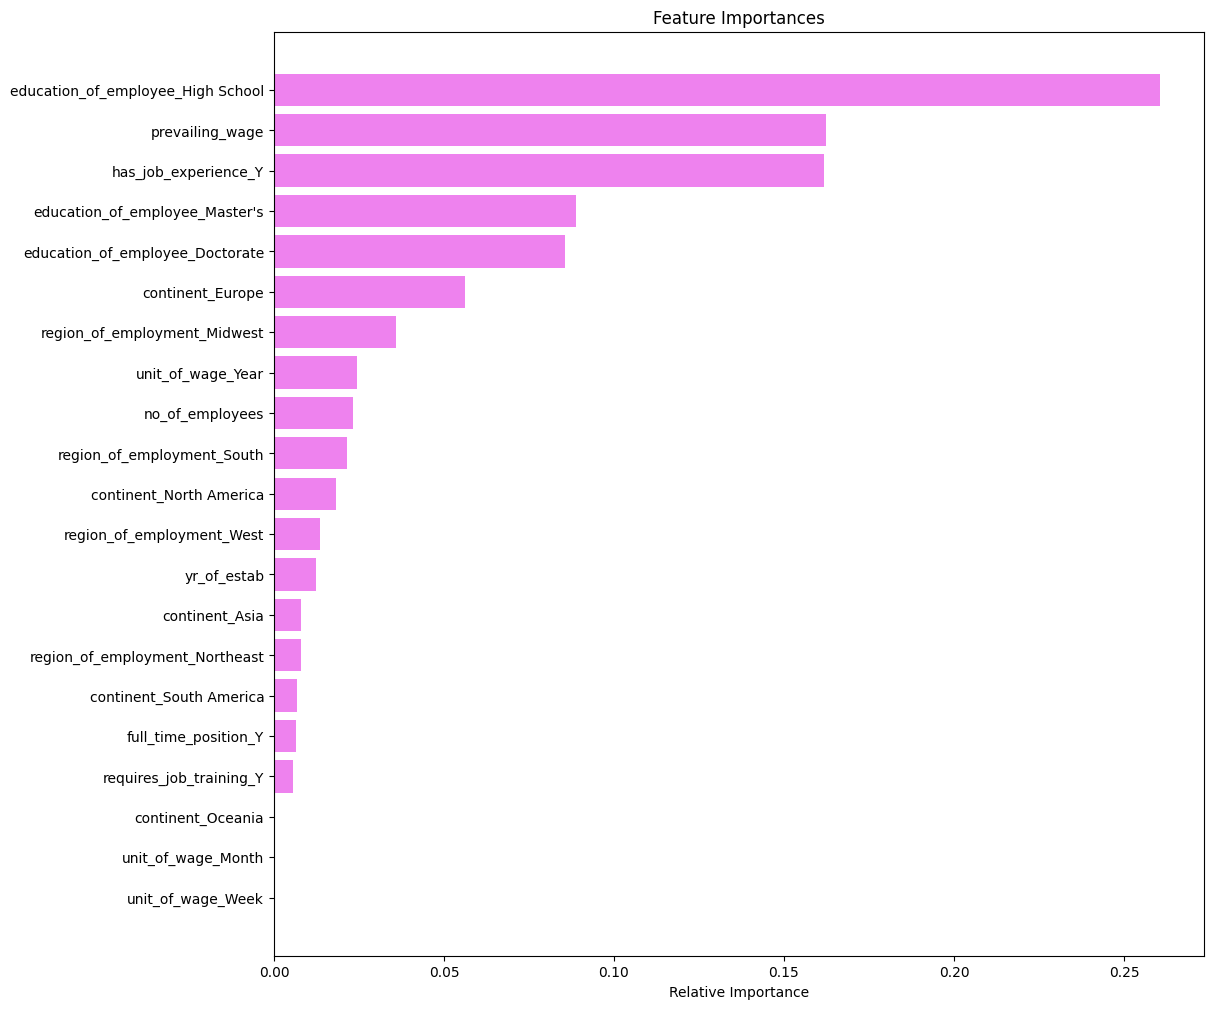

In [ ]:
feature_names = X_train.columns
importances = models["Gradient Boosting"].feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# **Actionable Insights and Recommendations**


* After analysis, I recommend proceeding with a Gradient Boosting model using the original dataset. Further model tuning is not required.

* Model performance summary
    * My approach from the beginning was to balance approving too many applicants and rejecting qualified applicants, causing me to select F1 score as my primary metric.
    * While the selected model reports a strong F1 Score (0.826), please note that the model still leans more aggressively, and is prone to approving too many applicants. Given the stakes and my initial focus on F1 Score, I believe it’s better to approve slightly too many applicants than turn away deserving applicants.

* Feature Importance Summary - three features played a strong role in determining likely visa approval/denial for an applicant.
    * Education of Employee = High School: An employee’s education stopping at the high school level served as the strong indicator for accept/deny (0.25)
    * Prevailing Wage: An employee’s existing salary (0.15)
    * Has Job Experience = Yes: An employee applying with previous job experience (0.15)

* Given the strong F1 score, I advise OFLC to adopt a machine learning based approach to handle the growing applicant volume. The existing data provides a solid foundation for an ML solution that will only improve as more data is collected.



___